# Enunciado de la Entrega de Aprendizaje Automático – Grado de Física

**Fecha de entrega:** 8 de enero a las 23.59 (un día antes del examen del 9 de enero)

**Objetivo:**  
En esta actividad (¡aprovechando el espíritu navideño para aprender! 🎄), hay que desarrollar y comparar modelos de *Machine Learning* tanto tradicionales como de *Deep Learning* empleando un conjunto de datos público. Se busca un enfoque práctico: experimentar con varios modelos, optimizar sus parámetros y extraer conclusiones sobre el rendimiento de cada enfoque. (Considerad esta entrega como un regalo académico anticipado 🎁: la oportunidad de demostrar todo lo aprendido en la asignatura).

# CÓDIgO Y REDACCIÓN DE INFORME

In [ ]:
# IMPORTAMOS LIBRERÍAS

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

1. **Selección del dataset:**  
   Escoge **uno** de los conjuntos de datos públicos sugeridos (ver lista más abajo). Puede ser tabular (datos estructurados) o de imágenes, según tu preferencia.

He escogido el dataset  **CIFAR-10** de clasificación de imágenes. 

In [ ]:
# Cogemos las imágenes de los dígitos asi como el conjunto de train y test
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

A continuación observamos las dimensiones de cada conjunto (el train que usaremos para entrenar la red y el test que usaremos para validar) y podemos observar que tenemos para entrenar (X_train) 50000 fotos de 32 x 32 que están en RGB, es decir, usa un canal de rojo, verde y azul. Para validar (X_test) usaremos 10000 fotos con las mismas características. Respecto al y_train muestra una etiqueta por imagen de entrenamiento (almacenadas como vector columna) y y_test.shape una etiqueta por imagen de test.

In [67]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


Además haremos una visualización de algunas imagenes para estudiar más el dataset

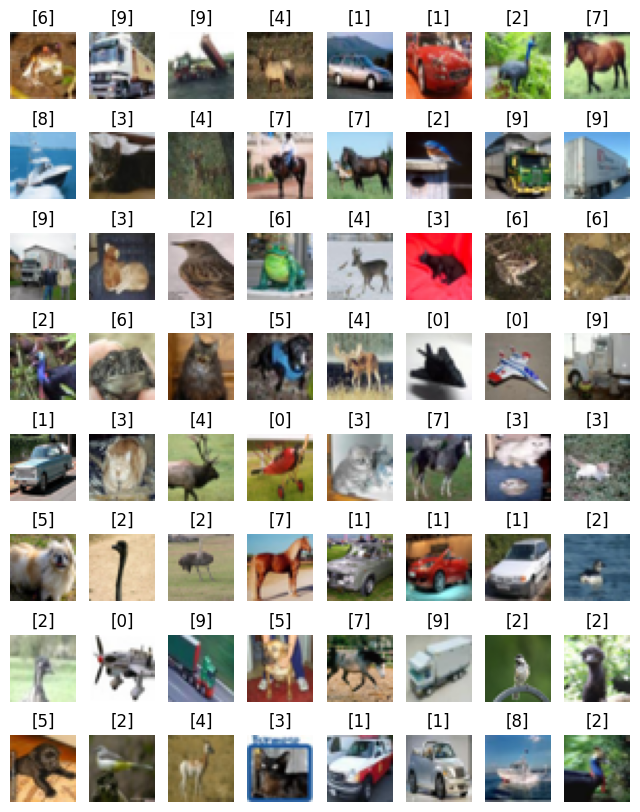

In [68]:
fig, axes = plt.subplots(8,8, figsize=(8,10)) 
for idx, ax in enumerate(axes.flat): 
    ax.imshow(X_train[idx], aspect='auto') 
    ax.axis('off') 
    ax.set_title(f"{y_train[idx]}") 

plt.subplots_adjust(hspace=0.5)
plt.show() 

Podemos comprobar que las asignaciones a los números de estas imágenes corresponden a categorías:

0 → avión

1 → coche

2 → pájaro

3 → gato

4 → ciervo

5 → perro

6 → rana

7 → caballo

8 → barco

9 → camión


2. **Preparación de los datos:**  
   Realiza una limpieza básica y preparación del dataset antes de entrenar. No es necesario invertir mucho tiempo en ingeniería de características; simplemente asegúrate de que los datos estén en un formato adecuado (ejemplo: manejo de valores ausentes, conversión de categorías a numérico si aplica, normalización si es pertinente). La idea es dejar el conjunto de datos “listo para usar” de forma sencilla, sin profundizar demasiado en esta fase.

Normalizamos para un mejor trabajo con las imágenes:

In [69]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255 

Dado que para futuras funciones a usar de deep learning (por ejemplo, en Keras que es una de las que usaremos) se necesita una forma del tipo (N,). Por ello, emplearemos la función .squeeze().

In [70]:
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

In [71]:
y_train.shape, y_test.shape

((50000,), (10000,))

Hacemos una media del valor de los píxeles normalizados para comprobar si hay más píxeles claros u oscuros. Podemos comprobar que al estar más próximo a 0 las imagenes son más oscuras que claras pero no por mucho.

In [72]:
np.mean(X_train)  

np.float32(0.473363)

Para comprobar la normalización mostramos el 1a imágen de entrenamiento y comprobamos que se ha normalizado correctamente.

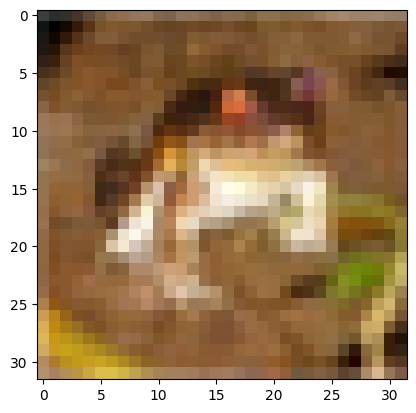

In [73]:
plt.imshow(X_train[0])

In [74]:
X_train[0].shape

(32, 32, 3)

3. **Entrenamiento de modelos:**  
   - Entrena **al menos un modelo de *Machine Learning* tradicional**, por ejemplo un *k*-NN, SVM o Random Forest, utilizando el dataset elegido. Prueba distintos hiperparámetros en este modelo clásico.  
   - Entrena **también un modelo de red neuronal** simple (una red *feed-forward* o una CNN si son imágenes) utilizando Keras (TensorFlow) con el mismo conjunto de datos. También aquí, experimenta con la arquitectura o parámetros (número de capas, neuronas, épocas, etc.) dentro de lo razonable.  
   - *Nota:* Si lo consideras adecuado, puedes **probar más modelos o enfoques adicionales** (por ejemplo, otro algoritmo tradicional, o una arquitectura de red diferente). Cualquier método novedoso o extra que pruebes será bien recibido *siempre que esté justificado en tu informe*. ¡Si tienes una idea creativa, adelante!


## K Nearest Neighbour (KNN)

In [75]:
# Librerías necesarias para entrenar el modelo.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

Para crear el modelo de KNN primero debemos hacer un flatten para trabajar sobre 2 dimensiones y no sobre 4 como tenemos inicialmente y comprobamos de nuevo las dimensiones de las variables.

In [76]:
# Flatten: (N, 32, 32, 3) -> (N, 3072)
X_train_knn = X_train.reshape(X_train.shape[0], -1)
X_test_knn  = X_test.reshape(X_test.shape[0], -1)

# Aseguramos que sea 1D (como hemos hecho anteriormente)
y_train_knn = y_train.squeeze()
y_test_knn  = y_test.squeeze()

In [77]:
print(X_train_knn.shape)
print(y_train_knn.shape)
print(X_test_knn.shape)
print(y_test_knn.shape)

(50000, 3072)
(50000,)
(10000, 3072)
(10000,)


Antes de entrenar el modeo con KNN, realizaremos una PCA para que trabaje con mayor fluidez. Para ello establecemos una parámetros para probar y localizar bajo cuales el modelo es mejor.

In [78]:
n_components_list = [30, 50, 75, 100, 125, 150]

best_score = -1
best_n = None

for n in n_components_list:
    print(f"\nProbando PCA con n_components = {n}")

    pca = PCA(
        n_components=n,
        whiten=False,              
        svd_solver="randomized",
        random_state=42
    )
    
    knn = KNeighborsClassifier()
    model = make_pipeline(pca, knn)

    gs_tmp = GridSearchCV(
        model,
        param_grid_knn,
        scoring="accuracy",
        refit="accuracy",
        cv=3,
        n_jobs=2,
        verbose=0
    )

    gs_tmp.fit(X_train_knn, y_train)
    score = gs_tmp.best_score_
    print("CV accuracy:", score)

    if score > best_score:
        best_score = score
        best_n = n



Probando PCA con n_components = 30
CV accuracy: 0.41511990473019056

Probando PCA con n_components = 50
CV accuracy: 0.3965998731147422

Probando PCA con n_components = 75
CV accuracy: 0.3903999275108701

Probando PCA con n_components = 100
CV accuracy: 0.382059884303334

Probando PCA con n_components = 125
CV accuracy: 0.3752999258987579

Probando PCA con n_components = 150
CV accuracy: 0.3711399034949818


Podemos observar que el mejor valor es n = 30 debido a su elevado valor de accuracy, aunque no sea un valor considerado 'perfecto' a la hora de predecir.

In [79]:
gs_tmp = GridSearchCV(
    model,
    param_grid_knn,
    scoring=scoring,
    refit="accuracy",
    cv=3,
    n_jobs=2,
    verbose=0
)

gs_tmp.fit(X_train_knn, y_train)
score = gs_tmp.best_score_

In [99]:
# Índice del mejor modelo según accuracy
best_i = gs_tmp.best_index_

print("Mejores parámetros:", gs_tmp.best_params_)
print("CV accuracy:", gs_tmp.cv_results_["mean_test_accuracy"][best_i])
print("CV precision:", gs_tmp.cv_results_["mean_test_precision_macro"][best_i])
print("CV recall:", gs_tmp.cv_results_["mean_test_recall_macro"][best_i])
print("CV F1:", gs_tmp.cv_results_["mean_test_f1_macro"][best_i])

Mejores parámetros: {'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__p': 1, 'kneighborsclassifier__weights': 'distance'}
CV accuracy: 0.41511990473019056
CV precision: 0.4506795673406394
CV recall: 0.4151210094115631
CV F1: 0.4107483089584547


Al igual que con el accuracy, los mejores valores de precision, recall y F1 está en el valor más bajo de las componentes que he establecido, voy a probar que ocurre a menores valores de n, por ello repito el proceso para valores pequeños. 

In [81]:
n_components_list = [5,10,20,30]

best_score = -1
best_n = None

for n in n_components_list:
    print(f"\nProbando PCA con n_components = {n}")

    pca = PCA(
        n_components=n,
        whiten=False,              
        svd_solver="randomized",
        random_state=42
    )
    
    knn = KNeighborsClassifier()
    model = make_pipeline(pca, knn)

    gs_tmp = GridSearchCV(
        model,
        param_grid_knn,
        scoring="accuracy",
        refit="accuracy",
        cv=3,
        n_jobs=2,
        verbose=0
    )

    gs_tmp.fit(X_train_knn, y_train)
    score = gs_tmp.best_score_
    print("CV accuracy:", score)

    if score > best_score:
        best_score = score
        best_n = n



Probando PCA con n_components = 5
CV accuracy: 0.28177995062443645

Probando PCA con n_components = 10
CV accuracy: 0.36293996428963776

Probando PCA con n_components = 20
CV accuracy: 0.40899996832656643

Probando PCA con n_components = 30
CV accuracy: 0.41511990473019056


In [82]:
gs_tmp = GridSearchCV(
    model,
    param_grid_knn,
    scoring=scoring,
    refit="accuracy",
    cv=3,
    n_jobs=2,
    verbose=0
)

gs_tmp.fit(X_train_knn, y_train)
score = gs_tmp.best_score_
print("CV accuracy:", score)

CV accuracy: 0.41511990473019056


In [83]:
# Índice del mejor modelo según accuracy
best_i = gs_tmp.best_index_

print("Mejores parámetros:", gs_tmp.best_params_)
print("CV accuracy:", gs_tmp.cv_results_["mean_test_accuracy"][best_i])
print("CV precision (macro):", gs_tmp.cv_results_["mean_test_precision_macro"][best_i])
print("CV recall (macro):", gs_tmp.cv_results_["mean_test_recall_macro"][best_i])
print("CV F1 (macro):", gs_tmp.cv_results_["mean_test_f1_macro"][best_i])

Mejores parámetros: {'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__p': 1, 'kneighborsclassifier__weights': 'distance'}
CV accuracy: 0.41511990473019056
CV precision (macro): 0.4506795673406394
CV recall (macro): 0.4151210094115631
CV F1 (macro): 0.4107483089584547


Podemos comprobar que el mejor valor sigue siendo para n = 30, aunque las métricas no dejan de ser muy bajas. 

## Convolution Neuronal Network (CNN)

Respecto al entrenamiento de la red neuroral he realizado un modelo de CNN ya que es un dataset de imágenes. La estructura inicial a seguir ha sido: 

Primero, comenzamos con una capa de entrada, seguida de un primer bloque formado por Conv2D con 32 filtros y activación ReLU para extraer características locales, MaxPooling2D para reducir dimensionalidad y Dropout para regularización. 

A continuación, se aplica un segundo bloque similar pero más profundo, con Conv2D de más filtros (64 filtros), MaxPooling2D y Dropout, aumentando la capacidad de representación. 

Después, aplanamos las características con un Flatten van a una capa densa de 256 neuronas con ReLU para combinar la información extraída, seguida de Dropout. 

Finalmente, aplicamos una capa Dense de 10 neuronas con activación softmax para producir las probabilidades de pertenencia a cada una de las 10 clases y así realizar la clasificación.

In [84]:
# Modelo (CIFAR-10)
model = keras.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [85]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,794 (4.08 MB)

 Trainable params: 1,070,794 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

Partiendo de imágenes de entrada 32x32x3, la primera capa Conv2D con padding “same” mantiene las dimensiones espaciales y genera 32 mapas de características, dando lugar a 32x32x32; el MaxPooling2D reduce a la mitad ancho y alto, pasando a 16×16×32, mientras que Dropout no altera la dimensionalidad. 

La segunda Conv2D vuelve a conservar el tamaño espacial pero aumenta la profundidad a 64, produciendo 16x16x64, y el segundo MaxPooling2D reduce nuevamente a 8x8x64, con Dropout manteniendo esta forma. 

Posteriormente, Flatten transforma el volumen 8x8x64 en un vector de 4096 componentes, que alimenta una capa densa de 256 neuronas, reduciendo la dimensionalidad a 256; tras otro Dropout, la capa final Dense de 10 neuronas proyecta ese vector en un espacio de dimensión 10, correspondiente a las clases de salida.

Respecto a los parámetros, en la primera Conv2D hay 896 parámetros, que provienen de (3x3x3)x32 pesos de los filtros (más 32 sesgos, importante recordar el bias); en la segunda Conv2D aparecen 18 496 parámetros, calculados como (3x3x32)x64 (más 64 sesgos), al aumentar la profundidad de entrada. 

Las capas MaxPooling, Dropout y Flatten no añaden parámetros porque solo transforman o regularizan los datos. El mayor número de parámetros está en la Dense de 256 neuronas    (1 048 832), ya que conecta completamente los 4096 valores de entrada con cada neurona, más sus sesgos. 

Finalmente, la Dense de salida tiene 2 570 parámetros, correspondientes a 256×10 pesos (más 10 sesgos). El total suma 1 070 794 parámetros, todos entrenables, lo que explica que la mayor capacidad (y riesgo de sobreajuste) del modelo esté concentrada en las capas densas.

In [86]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.3811 - loss: 1.6970 - val_accuracy: 0.5183 - val_loss: 1.3663
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.5130 - loss: 1.3602 - val_accuracy: 0.5909 - val_loss: 1.1962
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.5637 - loss: 1.2303 - val_accuracy: 0.6292 - val_loss: 1.0738
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.5979 - loss: 1.1412 - val_accuracy: 0.6543 - val_loss: 1.0098
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6201 - loss: 1.0756 - val_accuracy: 0.6758 - val_loss: 0.9491
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6400 - loss: 1.0210 - val_accuracy: 0.6856 - val_loss: 0.9168
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6546 - loss: 0.9804 - val_accuracy: 0.6873 - val_loss: 0.8938
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6662 - loss: 0.9466 - 

In [87]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6976 - loss: 0.8683


[0.8682824373245239, 0.6976000070571899]

Analizando los resultados, podemos observar un aprendizaje progresivo y estable del modelo a lo largo de las 10 épocas. 

La accuracy de entrenamiento aumenta de 0.35 a 0.67 mientras que la loss disminuye de 1.78 a 0.94, lo que indica que la red está ajustando correctamente sus parámetros a los datos de entrenamiento. 

Respecto a la accuracy de validación mejora de 0.49 a 0.71 y la val_loss desciende de 1.44 a 0.85, siguiendo una tendencia muy similar a la del entrenamiento. 

El hecho de que la accuracy de validación sea comparable, e incluso ligeramente superior en algunas épocas, y que no se observe un aumento de la val_loss, nos indica que no hay sobreajuste significativo y que el uso de Dropout está funcionando como regularizador. 

Por ello, podemos concluir que el modelo converge de forma razonable y que alcanza un rendimiento moderado que podría mejorarse con más épocas, data augmentation o una arquitectura más profunda. A continuación realizaremos alguna de estas pruebas.

Recordamos de nuevo cuales son las dimensiones así como de cuantas clases tenemos para clasificar las imagenes a entrenar.

In [88]:
print("X_train:", X_train.shape, X_train.dtype, X_train.min(), X_train.max())

y_train = y_train.squeeze()
y_test  = y_test.squeeze()

print("y_train:", y_train.shape, y_train.dtype)
print("clases únicas:", np.unique(y_train))
print("num clases:", len(np.unique(y_train)))
print("ejemplo y_train[0]:", y_train[0])

X_train: (50000, 32, 32, 3) float32 0.0 1.0
y_train: (50000,) uint8
clases únicas: [0 1 2 3 4 5 6 7 8 9]
num clases: 10
ejemplo y_train[0]: 6


In [96]:
# Asegura tipos y formas correctas
X_test_eval = np.asarray(X_test, dtype=np.float32)
y_test_eval = np.asarray(y_test).squeeze().astype(np.int32)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_eval, y_test_eval)).batch(256)

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print("CNN Test loss:", test_loss)
print("CNN Test accuracy:", test_acc)


CNN Test loss: 0.8682830333709717
CNN Test accuracy: 0.6976000070571899


Podemos comprobar que el modelo alcanza una accuracy en test de aproximadamente 0.70, lo que indica que clasifica correctamente cerca del 70 % de las imágenes, con una pérdida (loss) de alrededor de 0.86, coherente con el nivel de acierto obtenido. 

Podemos decir que el modelo entrenado tiene una buena capacidad de generalización, ya que el rendimiento en test es muy similar al observado en validación durante el entrenamiento, sin observar indicios sobreajuste. 

In [97]:
# Obtenemos predicciones del modelo
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Métricas 
precision = precision_score(y_test_eval, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test_eval, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test_eval, y_pred, average="macro", zero_division=0)

print("CNN Test precision:", precision)
print("CNN Test recall:", recall)
print("CNN Test F1:", f1)

print("\nClassification report (CNN):")
print(classification_report(y_test_eval, y_pred, zero_division=0))


CNN Test precision: 0.7111685871587771
CNN Test recall: 0.6976
CNN Test F1: 0.7016321776770253

Classification report (CNN):
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      1000
           1       0.84      0.83      0.84      1000
           2       0.56      0.60      0.58      1000
           3       0.49      0.50      0.49      1000
           4       0.66      0.65      0.65      1000
           5       0.52      0.71      0.60      1000
           6       0.84      0.70      0.77      1000
           7       0.78      0.74      0.76      1000
           8       0.86      0.76      0.81      1000
           9       0.79      0.77      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



A nivel general, la red alcanza una accuracy de aproximadamente 0.70, coherente con un recall de 0.70, una precisión de 0.71 y un F1  cercano a 0.70. El hecho de que estas métricas sean muy parecidas es debido a un equilibrio entre precisión y capacidad de detección, prediciendo a igual precisión todas las clases, por lo que es relevante en un problema multiclase como este.

El classification report por clases muestra que el modelo funciona especialmente bien en categorías visualmente más distinguibles, como las clases 1, 6 y 8 (coche, rana y barco), donde se obtienen valores de precision, recall y F1 superiores a 0.80, siendo por ello, estas las clases que mejor identifica. 

En cambio, las clases 2 y 3 (pájaro y gato) presentan métricas más bajas cerca del 0.5, lo que sugiere mayor solapamiento visual con otras categorías y, por tanto, mayor dificultad para el modelo. 

Aun así, ninguna clase queda claramente aislada a la hora de predecir, y todas mantienen valores razonables de recall.

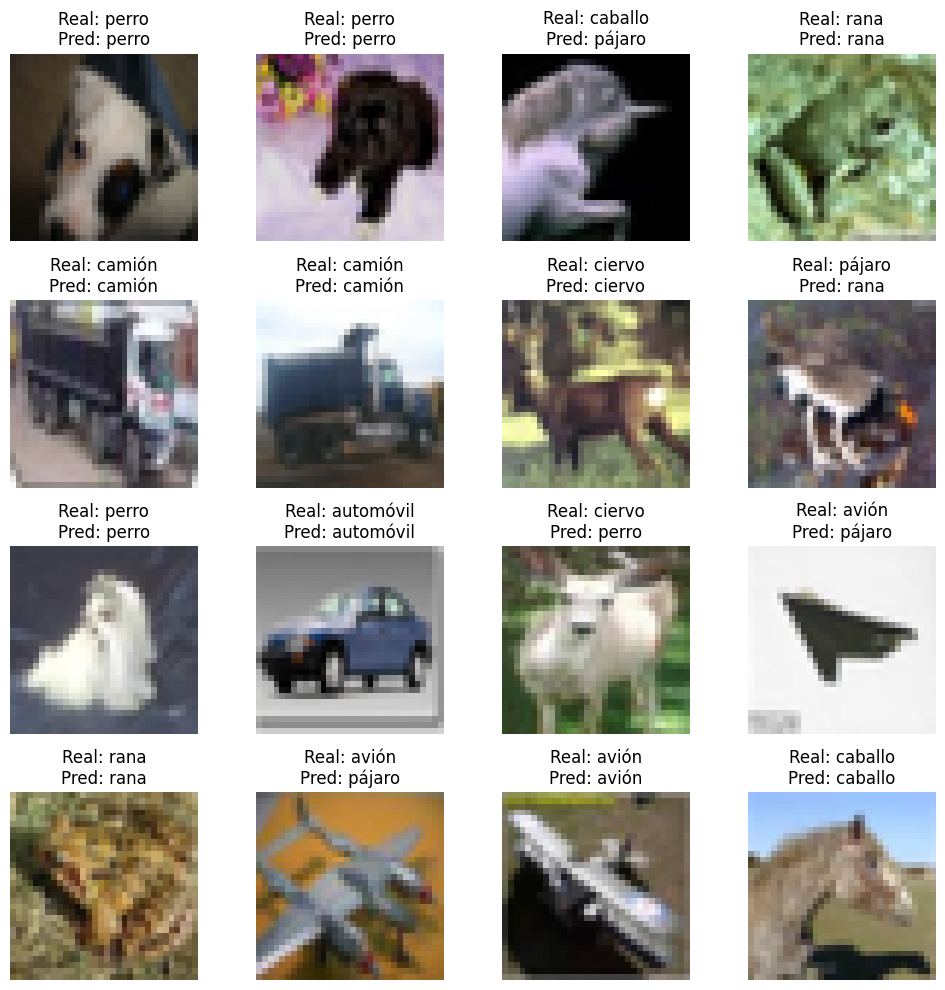

In [90]:
# Para que sea más facil de visualizar y entender en vez de números escribo la clase a la que pertenece.
class_names = ["avión","automóvil","pájaro","gato","ciervo","perro","rana","caballo","barco","camión"] 

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

plt.figure(figsize=(10,10))
for i in range(16):
    idx = np.random.randint(0, len(X_test))
    plt.subplot(4,4,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"Real: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


Con las predicciones de las imágenes podemos comprobar que, efectivamente, acierta con la clase a la que pertenece la imágen un 70% de las veces, tal y como se ha predecido anteriormente.

A continuación analizaremos las gráficas de relaciones para apoyar más el estudio de la efectividad del modelo.

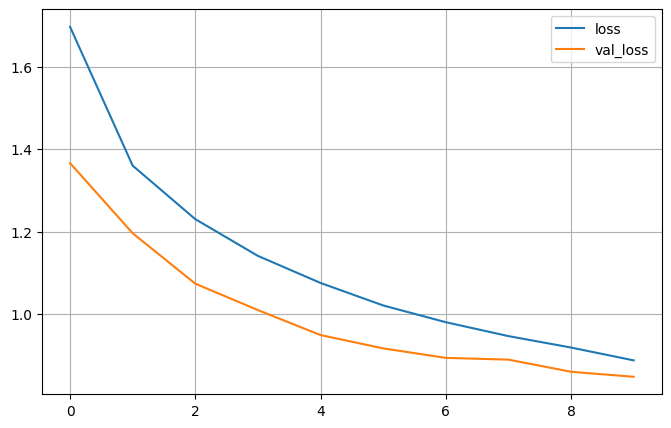

In [91]:
pd.DataFrame(history.history)[["loss", "val_loss"]].plot(figsize=(8, 5))
plt.grid(True)

Esta gráfica muestra la evolución de la función de pérdida durante el entrenamiento y la validación a lo largo de las épocas. 

Se observa una disminución progresiva y suave de la loss de entrenamiento, lo que indica que el modelo aprende de forma estable y va ajustando correctamente sus parámetros, cosa que también ocurre con la val_loss, que desciende de forma continua, manteniéndose incluso ligeramente por debajo de la loss de entrenamiento, lo cual es un comportamiento esperado al utilizar técnicas de regularización como Dropout. 

La ausencia de un aumento de la val_loss en las últimas épocas sugiere que no hay sobreajuste significativo y que el modelo generaliza adecuadamente.

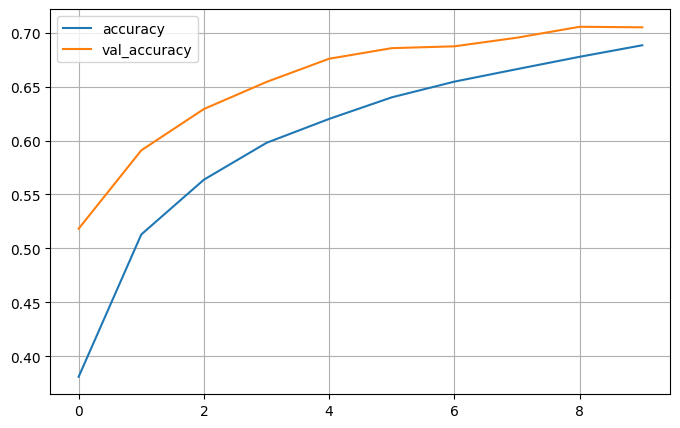

In [92]:
pd.DataFrame(history.history)[["accuracy", "val_accuracy"]].plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Esta otra gráfica representa la evolución del accuracy del modelo en entrenamiento y validación. 

La accuracy de entrenamiento aumenta de forma constante, mejorando la capacidad del modelo para clasificar correctamente los datos. A su vez, la val_accuracy sigue una tendencia similar y se mantiene ligeramente por encima de la de entrenamiento, lo que indica una buena generalización y confirma que el modelo no está memorizando los datos de entrenamiento. 

El crecimiento continuo y la estabilización de ambas curvas en torno al 70 % evidencian una convergencia correcta del entrenamiento y un comportamiento consistente entre entrenamiento y validación.

4. **Evaluación y comparación:**  
   Utiliza métricas adecuadas según el tipo de problema para evaluar los modelos. Por ejemplo, precisión, recall, F1 si es clasificación; o RMSE, MAE si es regresión. Compara el rendimiento de los modelos tradicionales vs. la red neuronal. ¿Cuál funciona mejor en tu caso y por qué? ¿Hay mucha diferencia entre ellos? Comenta posibles razones (tamaño de datos, hiperparámetros, capacidad del modelo, etc.). Puedes apoyar tus conclusiones con tablas o gráficas comparativas de las métricas.

In [101]:
# ================== Métricas KNN ==================
best_i = gs_tmp.best_index_

knn_metrics = {
    "Model": "KNN + PCA",
    "Accuracy": gs_tmp.cv_results_["mean_test_accuracy"][best_i],
    "Precision (macro)": gs_tmp.cv_results_["mean_test_precision_macro"][best_i],
    "Recall (macro)": gs_tmp.cv_results_["mean_test_recall_macro"][best_i],
    "F1 (macro)": gs_tmp.cv_results_["mean_test_f1_macro"][best_i]
}
# ================== Métricas CNN  ==================
cnn_metrics = {
    "Model": "CNN",
    "Accuracy": test_acc,
    "Precision (macro)": precision,
    "Recall (macro)": recall,
    "F1 (macro)": f1
}


# ================== Tabla comparativa ==================
df_comparison = pd.DataFrame([knn_metrics, cnn_metrics])

print(df_comparison)

       Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
0  KNN + PCA   0.41512           0.450680        0.415121    0.410748
1        CNN   0.69760           0.711169        0.697600    0.701632


Tras el entrenamiento de los modeos de los dos diferentes modos y calcular las correspondientes métricas, finalmente, podemos comprobar que el modelo de red neuronal CNN es mejor a la hora de clasificar imagenes y lo podemos comprobar observando dichos datos de las métricas accuracy, precision, F1 y recall. El modeo realizado con la red neuronal aprende mejor que el KNN realizado de forma tradicional. 

La diferencia entre el modelo de CNN y de KNN es de un 30% siendo peor KNN por lo que la diferencia es notable. También hay que tener en cuenta que no se ha podido poner valores en los parámetros debido al peso de dataset y el poca capacidad de procesado. Por ello, tanto en las épocas realizadas en la CNN y los valores de n para la PCA previa al KNN no he empleado valores muy elevados.

5. **Informe final:**  
   Elabora un informe breve (puede ser en Jupyter Notebook con Markdown o un documento aparte) donde expliques:  
   - **Proceso seguido:** cómo preparaste los datos, qué modelos entrenaste y cómo los configuraste.  
   - **Resultados:** compara las métricas obtenidas y discute cuál modelo rindió mejor. Incluye cualquier observación interesante (por ejemplo, “el modelo X sobreajustó”, “la red neuronal mejoró tras normalizar los datos”, etc.).  
   - **Conclusiones y mejoras:** propone posibles mejoras o siguientes pasos. Por ejemplo, ¿qué harías para mejorar el modelo si tuvieras más tiempo? ¿Añadir más datos, más features, ajustar algún parámetro? Además, reflexiona sobre **aplicaciones prácticas**: ¿a quién podría interesarle este modelo ya entrenado? ¿En qué contexto real sería útil la solución?  
   - Trata de darle un cierre reflexivo. (¡Piensa en esto como las conclusiones finales del año, con un guiño a las fiestas! 🎅✨)

En caso de haber disponido, ya no de más tiempo, sino de un ordenador con mayor potencia podría haber probado hiperparámetros más altos y haber probado más épocas en la CNN y haber metido más datos de cada clase de imágen para poder aumentar más aun la precisión del modelo. 

Finalmente, entre los posibles usos a dar a este modelo CNN de clasificación de imágenes puede usarse para identificar objetos perdidos o incluso en identificación de personas con rapidez, pero claro, tras mejorar más la precisión de este.